In [ ]:
# Resolve to the repo root so data/, figures/, and paper_figures/ paths work
# regardless of where the kernel started (this notebook lives in notebooks/).
import os
while not os.path.isdir("llm_polysemy") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")


# Paper Figures — *Where did the ambiguity go?*

A curated **subset** of `analysis.ipynb` that regenerates only the figures used in the
COLM paper, with the paper's exact model choices baked in (see the **Paper config** cell):

- **GLM is excluded** everywhere (the text panel is the 15-model, pre-GLM set).
- Per-figure family subsets follow the paper (e.g. family-separability uses the **big three**:
  OpenAI / Grok / Gemini — the families evaluated in *both* modalities).

Run top-to-bottom. Figures are written to `paper_figures/` as both `.pdf` (vector, for LaTeX)
and `.png` (preview). The setup + data-loading cells below are copied verbatim from
`analysis.ipynb` so the helpers (`get_vocab`, `dist_for`, `js`, `entropy`, …) behave identically.


In [1]:
import os, json, sys, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from itertools import combinations
from pathlib import Path
from scipy.spatial.distance import jensenshannon
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import pearsonr
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from IPython.display import display, HTML
import pandas as pd

# ipywidgets powers the interactive cells (sections 2 / 2b). It's optional — if
# it isn't installed in this kernel, those cells fall back to a static render.
try:
    import ipywidgets as widgets
    HAS_WIDGETS = True
except ModuleNotFoundError:
    widgets = None
    HAS_WIDGETS = False
    print('ipywidgets not found — interactive cells will render a static default '
          '(pip install ipywidgets to enable the dropdowns).')

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

# ── Working directory: find the project root wherever the notebook is run ──────
# Walk up from the current dir looking for the repo markers (the package + the
# data dir) instead of hard-coding an absolute path, so this runs on any machine.
def _find_project_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'llm_polysemy').is_dir() and (base / 'data' / 'meanings.json').is_file():
            return base
    raise FileNotFoundError(
        'Could not locate the llm-polysemy project root (a directory containing '
        'the `llm_polysemy/` package and `data/meanings.json`). Launch this '
        'notebook from inside the repo.')

PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

from llm_polysemy import registry
from llm_polysemy.registry import (
    FAMILY_ORDER, FAMILY_DISPLAY, FAMILY_COLOR,
    SENSE_PALETTE, EXTRA_LABELS, EXTRA_COLORS,
)


# ── Core analysis helpers ──────────────────────────────────────────
def get_senses(word):
    return [s['sense'] for s in meanings.get(word, [])]

def get_vocab(word, word_data, judge='gpt'):
    seen = set()
    judges = ('gpt', 'gemini') if judge == 'consensus' else (judge,)
    for m_data in word_data.values():
        for j in judges:
            node = m_data.get(j)
            if node:
                seen.update(node.get('_counts', {}).keys())
    vocab = get_senses(word)[:]
    for lbl in EXTRA_LABELS + sorted(seen):
        if lbl not in vocab:
            vocab.append(lbl)
    return vocab

def model_dist(counts, vocab):
    vec = np.array([counts.get(s, 0) for s in vocab], dtype=float)
    total = vec.sum()
    return vec / total if total > 0 else None

def dist_for(m_data, vocab, judge='gpt'):
    if judge == 'consensus':
        ds = []
        for j in ('gpt', 'gemini'):
            node = m_data.get(j)
            if node:
                d = model_dist(node.get('_counts', {}), vocab)
                if d is not None:
                    ds.append(d)
        if not ds: return None
        m = np.mean(ds, axis=0); s = m.sum()
        return m / s if s > 0 else None
    node = m_data.get(judge)
    if not node: return None
    return model_dist(node.get('_counts', {}), vocab)

def text_dist(word, vocab, freq):
    tf = freq.get(word, {})
    vec = np.array([tf.get(s, 0.0) for s in vocab], dtype=float)
    s = vec.sum()
    return vec / s if s > 0 else None

def js(p, q):
    """Jensen-Shannon *distance* (base-2): the square root of the JS distance.

    scipy.spatial.distance.jensenshannon returns the distance, not the divergence.
    The distance is a true metric bounded in [0, 1] — 0 when p == q, 1 when the
    two distributions share no support. That [0, 1] bound is exactly why `1 - js`
    is a valid similarity and why the matrix can be fed to hierarchical clustering
    (a metric, unlike a raw divergence). Labelled "JS distance" throughout."""
    return float(jensenshannon(p, q, base=2))

def entropy(p, base=2):
    """Shannon entropy of a probability vector, in bits (base-2).

    Measures how spread-out a model's sense choices are: 0 when it always picks a
    single sense, log2(k) when it splits its 30 samples evenly across k senses.
    Higher entropy = the model is more 'diverse' / less decisive for that word."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0]
    if p.size == 0:
        return np.nan
    return float(-np.sum(p * np.log(p) / np.log(base)))

def mean_pairwise_js(dists):
    pairs = list(combinations(dists, 2))
    if not pairs: return np.nan
    return float(np.mean([js(a, b) for a, b in pairs]))

def sense_colors(senses):
    colors = {s: SENSE_PALETTE[i % len(SENSE_PALETTE)] for i, s in enumerate(senses)}
    colors.update(EXTRA_COLORS)
    return colors

def family_of(key):  return registry.MODELS[key].family
def dlabel(key):     return registry.MODELS[key].label
def fcolor(fam):     return FAMILY_COLOR[fam]
def flabel(fam):     return FAMILY_DISPLAY[fam]

print('Setup complete.')


def canon_nent(m_data, word, judge='gpt'):
    """Normalized Shannon entropy over the word's CANONICAL senses only
    (fallback labels multiple/unclear/other dropped, then renormalized)."""
    sv = [s['sense'] for s in meanings.get(word, [])]
    if len(sv) < 2: return None
    counts = (m_data.get(judge) or {}).get('_counts', {})
    vec = np.array([counts.get(s, 0) for s in sv], float)
    if vec.sum() == 0: return None
    p = vec / vec.sum(); p = p[p > 0]
    return float(-(p * np.log2(p)).sum()) / np.log2(len(sv))


Project root: /Users/addisonwu/Desktop/llm-polysemy
Setup complete.


In [2]:
# ── Load all data ─────────────────────────────────────────────
hist_image  = json.loads(Path('data/histograms_image.json').read_text())
hist_text   = json.loads(Path('data/histograms_text.json').read_text())
meanings    = json.loads(Path('data/meanings.json').read_text())
freq_manual = json.loads(Path('data/freq_manual.json').read_text())
freq_wiki   = json.loads(Path('data/freq_wiki.json').read_text())

IMAGE_MODELS = registry.models_for('image')
TEXT_MODELS  = registry.models_for('text')
IMAGE_WORDS  = sorted(hist_image.keys())
TEXT_WORDS   = sorted(hist_text.keys())
BOTH_WORDS   = sorted(set(IMAGE_WORDS) & set(TEXT_WORDS))

print(f'Image histogram:  {len(IMAGE_WORDS)} words  ×  {len(IMAGE_MODELS)} models')
print(f'Text histogram:   {len(TEXT_WORDS)} words  ×  {len(TEXT_MODELS)} models')
print(f'Words in both:    {len(BOTH_WORDS)}')
print(f'\nWords with both modalities: {BOTH_WORDS}')

Image histogram:  100 words  ×  17 models
Text histogram:   100 words  ×  17 models
Words in both:    100

Words with both modalities: ['amazon', 'anchor', 'apple', 'ash', 'ball', 'band', 'bank', 'bar', 'bark', 'barrel', 'basket', 'bass', 'bat', 'batter', 'beam', 'bench', 'block', 'bolt', 'bow', 'bowl', 'box', 'bridge', 'brush', 'buck', 'bug', 'button', 'cane', 'cape', 'capital', 'cardinal', 'case', 'cast', 'cell', 'charge', 'chest', 'chip', 'club', 'coach', 'cobbler', 'cobra', 'crane', 'crown', 'drill', 'fan', 'file', 'fire', 'fly', 'fox', 'grave', 'hide', 'iron', 'jack', 'jaguar', 'jordan', 'key', 'lodge', 'mars', 'match', 'mercury', 'mine', 'mole', 'mortar', 'mustang', 'nail', 'paddle', 'pen', 'pitch', 'pitcher', 'plane', 'pool', 'port', 'post', 'press', 'pump', 'python', 'ram', 'ring', 'rock', 'scale', 'seal', 'shot', 'shuttle', 'socket', 'spring', 'staple', 'stock', 'strike', 'switch', 'tank', 'tap', 'tie', 'tip', 'toast', 'track', 'train', 'trunk', 'turkey', 'watch', 'wave', 'wil

In [3]:
# ── Paper config: model subsets + shared figure style ──────────────────────
import os
import matplotlib as mpl
os.makedirs('paper_figures', exist_ok=True)
FIGDIR = 'paper_figures'

def _fam(m):                       # family of a model key (glm_image -> 'glm')
    return 'glm' if m == 'glm_image' else family_of(m)

IMAGE_MODELS_PAPER = [m for m in registry.models_for('image') if _fam(m) != 'glm']
TEXT_MODELS_PAPER  = [m for m in registry.models_for('text')  if _fam(m) != 'glm']
BIG3 = ['openai', 'grok', 'gemini']

# ── Shared style (Figure & Table Guide): Arial, larger text, faint dashed
#    grid, vector PDF with embedded/selectable fonts. Applied to every figure.
mpl.rcParams.update({
    'font.family':     'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size':       14,
    'axes.titlesize':  15,
    'axes.labelsize':  14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi':      110,
    'axes.axisbelow':  True,
    'axes.grid':       False,
    'axes.grid.axis':  'y',
    'grid.linestyle':  '--',
    'grid.linewidth':  0.6,
    'grid.alpha':      0.45,
    'savefig.bbox':    'tight',
    'pdf.fonttype':    42,         # embed TrueType so PDF text stays selectable
    'ps.fonttype':     42,
})

# Consistent palette (Figure Guide recommended colors)
C_IMG   = '#1b76d2'   # image models / "models"
C_TXT   = '#dc8969'   # text models
C_HUMAN = '#483e8c'   # humans
C_GRAY  = '#c2c2c2'   # de-emphasized bars

def savefig(fig, name):
    fig.savefig(f'{FIGDIR}/{name}.pdf', bbox_inches='tight')
    fig.savefig(f'{FIGDIR}/{name}.png', dpi=200, bbox_inches='tight')
    print(f'saved  {FIGDIR}/{name}.pdf  +  .png')

print('Paper config + style ready.')


Paper config + style ready.


## Figure: core modality gap + human baselines (Fig. modality_gap)

Per-family image vs text model entropy (bars, incl. GLM), with the **human baselines overlaid
as dashed horizontal lines** (one per modality: blue = image, orange = text). The wide gap
between the bars and the dashed ceilings is the human-model gap. Regenerates `Modality_GAP.pdf`.


saved  paper_figures/modality_gap.pdf  +  .png


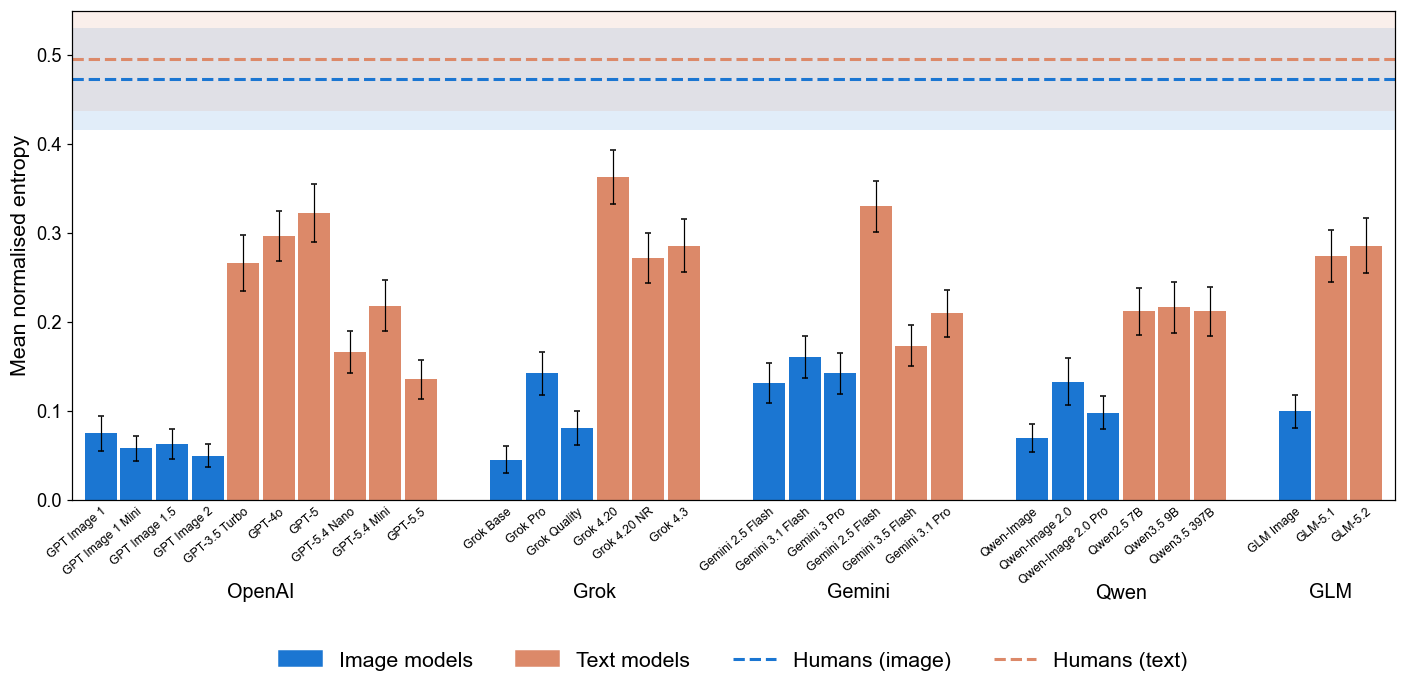

bars=31  human image=0.473±0.057  text=0.496±0.058


In [4]:
# ── Figure: per-model modality gap by family + human baselines (CI bands) ────
GAP_FAMS = ['openai', 'grok', 'gemini', 'qwen', 'glm']
img_by_fam = {f: [] for f in GAP_FAMS}; txt_by_fam = {f: [] for f in GAP_FAMS}
for m in registry.models_for('image'):
    if family_of(m) in GAP_FAMS: img_by_fam[family_of(m)].append(m)
img_by_fam['glm'].append('glm_image')
for m in registry.models_for('text'):
    if family_of(m) in GAP_FAMS: txt_by_fam[family_of(m)].append(m)
_gen = lambda m: registry.MODELS[m].generation_index if m in registry.MODELS else 0

def _model_cells(m, hist):
    vals = []
    for w in BOTH_WORDS:
        if w not in hist or m not in hist[w]: continue
        v = canon_nent(hist[w][m], w)          # canonical senses only (fallback excluded)
        if v is not None: vals.append(v)
    return np.array(vals)

# human baselines + 95% CI band
hist_hm = json.load(open('data/histograms_human_meaning.json'))
hist_hi = json.load(open('data/histograms_human_image.json'))
HW = [w for w in BOTH_WORDS if w in hist_hm and w in hist_hi]
def _human_vals(hist):
    vals = []
    for w in HW:
        if w not in hist or 'human' not in hist[w]: continue
        v = canon_nent(hist[w]['human'], w)     # canonical senses only
        if v is not None: vals.append(v)
    return np.array(vals)
hi, ht = _human_vals(hist_hi), _human_vals(hist_hm)
h_img, ci_img = hi.mean(), 1.96 * hi.std(ddof=1) / np.sqrt(len(hi))
h_txt, ci_txt = ht.mean(), 1.96 * ht.std(ddof=1) / np.sqrt(len(ht))

# lay out one bar per sub-model, grouped by family (image bars then text bars)
_dlab = lambda m: registry.MODELS[m].label if m in registry.MODELS else ('GLM Image' if m == 'glm_image' else m)
pos, hgt, err, col, centers, labels, barlab = [], [], [], [], [], [], []
x, gap = 0.0, 1.4
for f in GAP_FAMS:
    start = x
    for m in sorted(img_by_fam[f], key=_gen):
        c = _model_cells(m, hist_image)
        if not len(c): continue
        pos.append(x); hgt.append(c.mean()); err.append(c.std(ddof=1)/np.sqrt(len(c))); col.append(C_IMG); barlab.append(_dlab(m)); x += 1
    for m in sorted(txt_by_fam[f], key=_gen):
        c = _model_cells(m, hist_text)
        if not len(c): continue
        pos.append(x); hgt.append(c.mean()); err.append(c.std(ddof=1)/np.sqrt(len(c))); col.append(C_TXT); barlab.append(_dlab(m)); x += 1
    centers.append((start + x - 1) / 2); labels.append(flabel(f)); x += gap

fig, ax = plt.subplots(figsize=(13, 5.8))
ax.bar(pos, hgt, width=0.9, yerr=err, color=col, capsize=2, error_kw={'lw': 0.8})
ax.axhspan(h_img - ci_img, h_img + ci_img, color=C_IMG, alpha=0.13, lw=0)
ax.axhline(h_img, ls='--', lw=2, color=C_IMG, label='Humans (image)')
ax.axhspan(h_txt - ci_txt, h_txt + ci_txt, color=C_TXT, alpha=0.13, lw=0)
ax.axhline(h_txt, ls='--', lw=2, color=C_TXT, label='Humans (text)')

ax.set_xticks(pos)
ax.set_xticklabels(barlab, rotation=40, ha='right', rotation_mode='anchor', fontsize=8)
ax.tick_params(axis='x', length=0)
for _c, _l in zip(centers, labels):            # family names dropped below the model names
    ax.text(_c, -0.17, _l, transform=ax.get_xaxis_transform(), ha='center', va='top', fontsize=13)
ax.set_xlim(pos[0] - 0.8, pos[-1] + 0.8)
ax.set_yticks(np.arange(0, 0.55, 0.1)); ax.set_ylim(0, 0.55)
ax.set_ylabel('Mean normalised entropy')
plt.tight_layout()
from matplotlib.patches import Patch
_line_h, _line_l = ax.get_legend_handles_labels()
ax.legend(handles=[Patch(color=C_IMG, label='Image models'), Patch(color=C_TXT, label='Text models')] + _line_h,
          loc='upper center', bbox_to_anchor=(0.5, -0.27), ncol=4, frameon=False, fontsize=14)
savefig(fig, 'modality_gap')
plt.show()
print(f'bars={len(pos)}  human image={h_img:.3f}±{ci_img:.3f}  text={h_txt:.3f}±{ci_txt:.3f}')


## Figure: Entropy vs generation (claim 4.2.2)

Each model's mean normalized entropy (full merged vocab, gpt judge) against its registry
`generation_index` (1 = oldest), per family. **GLM excluded**, Qwen included. Text diversity
falls with newer models (Spearman ρ ≈ -0.60); image is flat and sits far lower
throughout. Shared y-axis makes the image-vs-text floor gap visible.

**Error bars** = ± 1 SEM across the 100 words (each word contributes one entropy value),
the same convention as the modality-gap bars.


In [ ]:
# ── Figure: sense diversity vs model generation (normalized), text vs image ──
from scipy.stats import spearmanr
from collections import defaultdict

def _mme(hist, m):
    """Mean normalized entropy for model m, plus the standard error over words.

    Each word contributes one entropy value, so the spread across the 100 words is
    the sampling variation the error bar should show (same convention as the
    modality-gap bars: +/- 1 SEM over words)."""
    vals = []
    for w in BOTH_WORDS:
        if w not in hist or m not in hist[w]:
            continue
        v = canon_nent(hist[w][m], w)            # canonical senses only
        if v is not None:
            vals.append(v)
    if not vals:
        return np.nan, np.nan
    a = np.asarray(vals, float)
    return a.mean(), (a.std(ddof=1) / np.sqrt(len(a)) if len(a) > 1 else np.nan)

_gen = lambda m: registry.MODELS[m].generation_index
_IMG_NOFLUX = [m for m in IMAGE_MODELS_PAPER if _fam(m) != 'flux']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3), sharey=True)
for ax, (modality, models) in zip(axes, [('text', TEXT_MODELS_PAPER), ('image', _IMG_NOFLUX)]):
    hist = hist_text if modality == 'text' else hist_image
    byf = defaultdict(list)
    for m in models:
        e, se = _mme(hist, m)
        if not np.isnan(e):
            byf[_fam(m)].append((_gen(m), e, se))
    allx, ally = [], []
    for f, xs in byf.items():
        xs = sorted(xs); n = len(xs)
        xn = [k / (n - 1) if n > 1 else 0.5 for k in range(n)]   # normalize each family to [0, 1]
        yy = [e for _, e, _ in xs]
        ee = [s for _, _, s in xs]
        ax.errorbar(xn, yy, yerr=ee, fmt='-o', color=fcolor(f), label=flabel(f),
                    ms=6, lw=2, capsize=3, elinewidth=1.2, capthick=1.2, zorder=3)
        allx += xn; ally += yy
    rho, p = spearmanr(allx, ally)
    ax.set_title(modality.capitalize())
    ax.set_xlabel(r'model generation (oldest $\rightarrow$ newest)')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['oldest', 'newest'])
    ax.set_yticks(np.arange(0, 0.45, 0.1))
    print(f'{modality}: rho={rho:+.2f}  p={p:.3f}  (n={len(allx)})')
axes[0].set_ylabel('mean normalized entropy')
axes[0].set_ylim(bottom=0)
from matplotlib.lines import Line2D
_fams = ['openai', 'grok', 'gemini', 'qwen']
_handles = [Line2D([0], [0], color=fcolor(f), marker='o', lw=2, label=flabel(f)) for f in _fams]
fig.legend(handles=_handles, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4, frameon=False)
plt.tight_layout()
savefig(fig, 'entropy_vs_generation')
plt.show()


## Figure: FLUX superposition (claim 4.2.3)

Per-model rate at which the judges label a generated image as depicting *multiple* senses
at once (superposition), over the official 17-model image panel. FLUX (diffusion) bars are
highlighted; the effect is concentrated in the FLUX.2 variants. FLUX mean 6.6% vs 0.9% for
every other family (model-level Mann-Whitney p = 0.01).

**Error bars** = ± 1 clustered SE from a word-level bootstrap (2000 resamples of the 100
words). Superposition is strongly word-dependent, so a plain binomial SE over the ~3000
samples would understate the uncertainty by 2-4×; the FLUX.2 gap survives either way.


In [ ]:
# ── Figure: superposition (multiple-sense) rate per image model ─────────────
def _mult_counts(m):
    """Per-word (n_multiple, n_samples) for image model m."""
    mult, tot = [], []
    for w in sorted(hist_image):
        node = hist_image[w].get(m, {}).get('gpt')
        if not node:
            mult.append(0.0); tot.append(0.0); continue
        c = node.get('_counts', {})
        mult.append(float(c.get('multiple', 0)))
        tot.append(float(sum(c.values())))
    return np.asarray(mult), np.asarray(tot)

def _mult_rate_se(m, B=2000, seed=0):
    """Pooled superposition rate + a *clustered* standard error.

    The 30 samples of a word are not independent draws — some words are
    intrinsically far more superposition-prone than others, so a plain binomial SE
    over all ~3000 samples understates the uncertainty by 2-4x. Instead resample
    whole WORDS with replacement (cluster bootstrap) and take the SD of the
    resampled pooled rates. Bar height is unchanged: still the pooled rate."""
    mult, tot = _mult_counts(m)
    if tot.sum() == 0:
        return np.nan, np.nan
    rate = mult.sum() / tot.sum()
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(mult), size=(B, len(mult)))
    bm, bt = mult[idx].sum(1), tot[idx].sum(1)
    boot = np.where(bt > 0, bm / np.where(bt > 0, bt, 1.0), np.nan)
    return rate, float(np.nanstd(boot, ddof=1))

panel = registry.models_for('image')                       # official 17, no GLM
rates = sorted([(m, _fam(m), *_mult_rate_se(m)) for m in panel], key=lambda x: -x[2])

fig, ax = plt.subplots(figsize=(10, 4.6))
colors = [C_IMG if f == 'flux' else C_GRAY for _, f, _, _ in rates]
ax.bar(range(len(rates)), [r * 100 for _, _, r, _ in rates], color=colors,
       yerr=[se * 100 for _, _, _, se in rates], capsize=2.5,
       error_kw={'lw': 0.9, 'ecolor': '#333333'})
ax.set_xticks(range(len(rates)))
ax.set_xticklabels([dlabel(m) for m, _, _, _ in rates], rotation=55, ha='right', fontsize=10)
ax.set_yticks(np.arange(0, 15, 2))
ax.set_ylabel('superposition rate (%)')
from matplotlib.patches import Patch
plt.tight_layout()
savefig(fig, 'flux_superposition')
plt.show()
for m, f, r, se in rates:
    print(f'{dlabel(m):24s} {f:7s}  {r*100:5.2f}% ± {se*100:.2f} (clustered SE)')


## Figure: inter-model similarity heatmaps (claim 4.2.1)

Model x model mean pairwise Jensen-Shannon similarity ($1 - $ mean JS distance), for the
**big three** families (OpenAI / Grok / Gemini) evaluated in both modalities. Both panels
share one color scale and a family -> generation ordering. Image models are markedly more
alike (greener) than text models: mean pairwise JS 0.22 vs 0.32 (paired Wilcoxon p < 1e-3).


saved  paper_figures/similarity_big3.pdf  +  .png


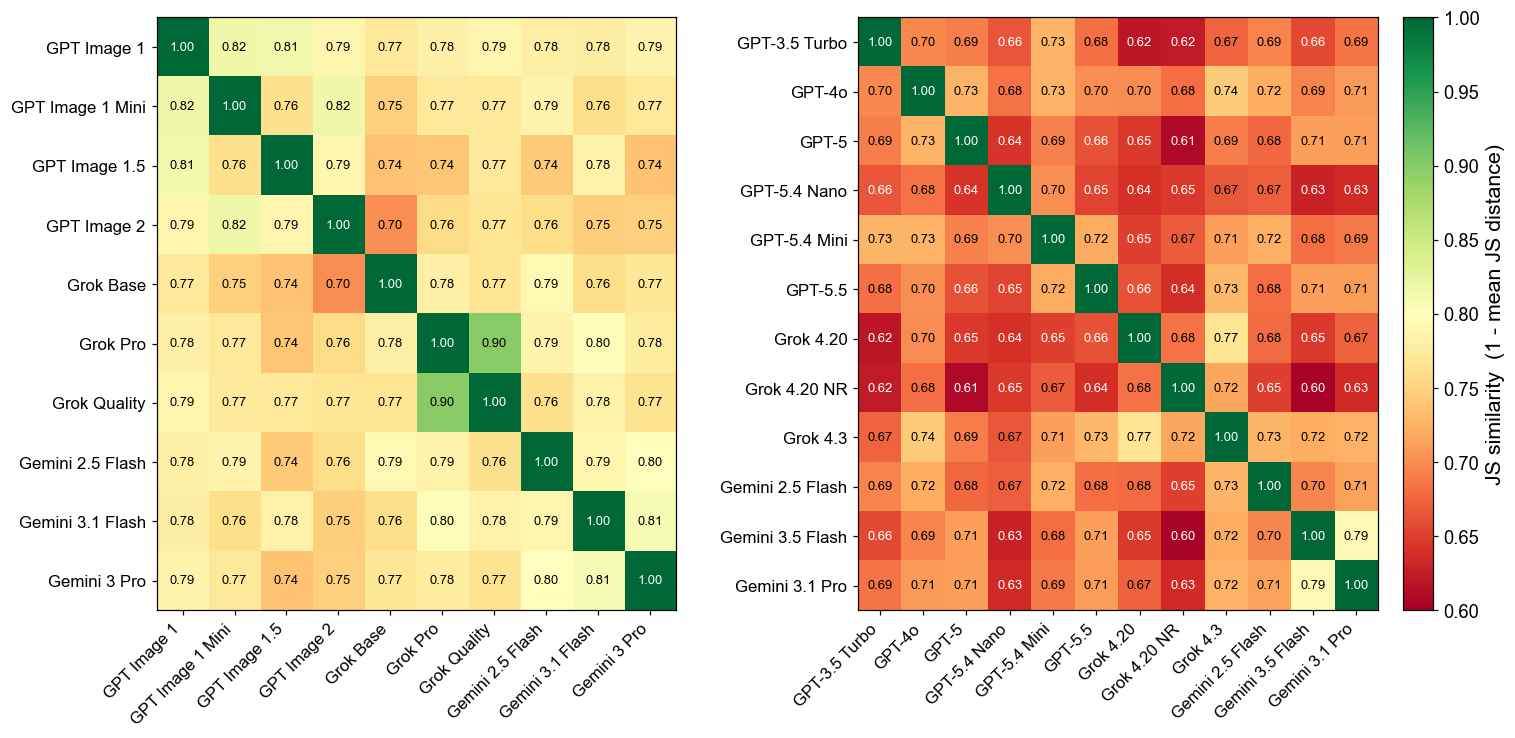

In [7]:
# ── Figure: big-3 model x model similarity heatmaps, image vs text ──────────
from itertools import combinations

def _sim_matrix(modality):
    hist   = hist_image if modality == 'image' else hist_text
    models = [m for m in registry.models_for(modality) if _fam(m) in BIG3]
    fr = {f: i for i, f in enumerate(FAMILY_ORDER)}
    models = sorted(models, key=lambda m: (fr.get(_fam(m), 99),
                    registry.MODELS[m].generation_index if m in registry.MODELS else 0, dlabel(m)))
    n = len(models)
    S = np.zeros((n, n)); C = np.zeros((n, n))
    for w, wd in hist.items():
        vocab = get_vocab(w, wd, 'gpt')
        d = {i: dist_for(wd[m], vocab, 'gpt') for i, m in enumerate(models) if m in wd}
        d = {i: x for i, x in d.items() if x is not None}
        for i in d:
            for j in d:
                if i >= j: continue
                v = js(d[i], d[j]); S[i, j] += v; S[j, i] += v; C[i, j] += 1; C[j, i] += 1
    with np.errstate(invalid='ignore'):
        avg = np.where(C > 0, S / C, np.nan)
    np.fill_diagonal(avg, 0.0)
    sim = 1 - avg
    mean_js = np.nanmean(avg[~np.eye(n, dtype=bool)])
    return sim, [dlabel(m) for m in models], mean_js

sim_i, lab_i, js_i = _sim_matrix('image')
sim_t, lab_t, js_t = _sim_matrix('text')
vmin = np.floor(min(sim_i[sim_i < 1].min(), sim_t[sim_t < 1].min()) * 20) / 20  # shared, to .05
vmax = 1.0
from matplotlib.colors import Normalize
_cmap = plt.get_cmap('RdYlGn'); _norm = Normalize(vmin=vmin, vmax=vmax)
def _txtcol(v):
    r, g, b, _ = _cmap(_norm(v))
    return 'black' if (0.299*r + 0.587*g + 0.114*b) > 0.5 else 'white'

fig, axes = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw={'wspace': 0.35})
for ax, (sim, lab, mj, title) in zip(axes, [(sim_i, lab_i, js_i, 'Image'),
                                            (sim_t, lab_t, js_t, 'Text')]):
    ax.grid(False)
    im = ax.imshow(sim, vmin=vmin, vmax=vmax, cmap='RdYlGn', aspect='auto')
    n = len(lab)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(lab, rotation=45, ha='right', fontsize=11)
    ax.set_yticklabels(lab, fontsize=11)
    for i in range(n):
        for j in range(n):
            v = sim[i, j]
            if not np.isnan(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=8.5, color=_txtcol(v))
fig.colorbar(im, ax=axes, label='JS similarity  (1 - mean JS distance)', fraction=0.025, pad=0.02)
savefig(fig, 'similarity_big3')
plt.show()


## Figure: cross-modality PCA (modality vs provider identity)

All 17 image + 15 text models embedded in one sense-distribution space, PCA to 2D. Left: colored by modality; right: by provider family. Models separate by modality (silhouette +0.27), not family (-0.04). Regenerates `cross_pca.pdf`.


silhouette: modality=+0.274  family=-0.044   PC1=15% PC2=12%
saved  paper_figures/cross_pca.pdf  +  .png


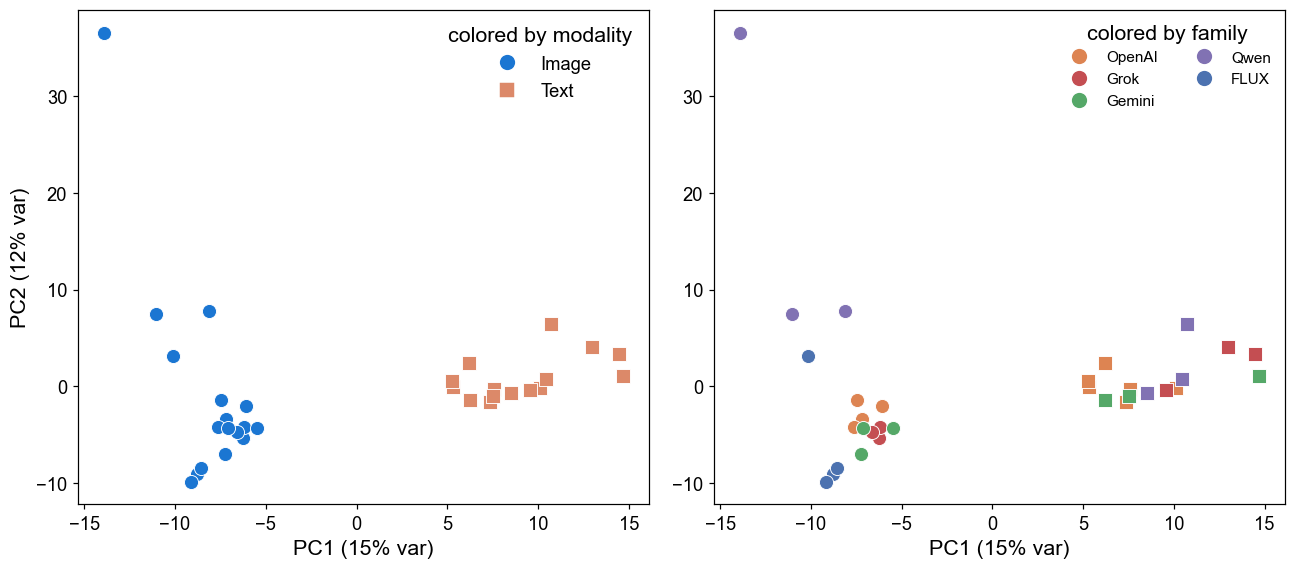

In [8]:
# ── Figure: cross-modality PCA — modality vs provider identity ──────────────
from sklearn.metrics import silhouette_score
from matplotlib.lines import Line2D

shared = sorted(set(hist_image) & set(hist_text))
IMG = registry.models_for('image')          # 17
TXT = TEXT_MODELS_PAPER                       # 15 (GLM-free)
blocks = [(w, get_vocab(w, {**hist_image.get(w, {}), **hist_text.get(w, {})}, 'gpt')) for w in shared]
rows, labels = [], []
for m, mod, hist in [(m, 'image', hist_image) for m in IMG] + [(m, 'text', hist_text) for m in TXT]:
    vec = []
    for w, v in blocks:
        node = hist.get(w, {}).get(m)
        d = dist_for(node, v, 'gpt') if node is not None else None
        vec.extend(d if d is not None else np.zeros(len(v)))
    rows.append(vec); labels.append((m, mod))

X = StandardScaler().fit_transform(np.array(rows))
pca = PCA(n_components=2, random_state=42).fit(X)
xy, var = pca.transform(X), pca.explained_variance_ratio_
X10 = PCA(n_components=10, random_state=42).fit_transform(X)
mod_lab = np.array([0 if mm == 'image' else 1 for _, mm in labels])
fam_lab = np.array([FAMILY_ORDER.index(_fam(m)) for m, _ in labels])
sm = silhouette_score(X10, mod_lab); sf = silhouette_score(X10, fam_lab)
print(f'silhouette: modality={sm:+.3f}  family={sf:+.3f}   PC1={var[0]:.0%} PC2={var[1]:.0%}')

MK = {'image': 'o', 'text': 's'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
for i, (m, mod) in enumerate(labels):
    axes[0].scatter(xy[i, 0], xy[i, 1], marker=MK[mod], s=85,
                    c=(C_IMG if mod == 'image' else C_TXT), edgecolors='white', linewidths=0.6, zorder=3)
    axes[1].scatter(xy[i, 0], xy[i, 1], marker=MK[mod], s=85,
                    c=fcolor(_fam(m)), edgecolors='white', linewidths=0.6, zorder=3)
for ax in axes:
    ax.set_xlabel(f'PC1 ({var[0]:.0%} var)')
axes[0].set_ylabel(f'PC2 ({var[1]:.0%} var)')
axes[0].legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor=C_IMG, ms=11, label='Image'),
                        Line2D([0], [0], marker='s', color='w', markerfacecolor=C_TXT, ms=11, label='Text')],
               frameon=False, loc='best', fontsize=12, title='colored by modality')
_fp = [f for f in FAMILY_ORDER if f in {_fam(m) for m, _ in labels}]
axes[1].legend(handles=[Line2D([0], [0], marker='o', color='w', markerfacecolor=fcolor(f), ms=11, label=flabel(f)) for f in _fp],
               frameon=False, loc='best', fontsize=10, title='colored by family', ncol=2)
plt.tight_layout()
savefig(fig, 'cross_pca')
plt.show()


## Deploy figures into the paper

Copies the figures generated above into the Overleaf paper repo under the **paper's**
filenames, so the figures in the paper are always exactly what this notebook produces.
Run this last. (The `flux_superposition` figure is generated but not currently placed in
the paper, so it is not deployed.)


In [9]:
# ── Deploy: push generated figures into the Overleaf paper, with paper names ─
import shutil, glob

# notebook figure name -> filename the paper's \includegraphics expects (vector PDF)
PAPER_FIG_NAMES = {
    'modality_gap':          'Modality_GAP.pdf',
    'similarity_big3':       'model_similarity.pdf',
    'entropy_vs_generation': 'model_lineage.pdf',
    'flux_superposition':    'flux_superposition.pdf',
    'cross_pca':             'cross_pca.pdf',
}

paper_root = None
for cand in sorted(glob.glob(str(PROJECT_ROOT / '*'))):
    if (Path(cand) / 'COLM' / 'colm2026_conference.tex').is_file():
        paper_root = Path(cand); break

if paper_root is None:
    print('paper repo not found under', PROJECT_ROOT, '- skipping deploy')
else:
    for nb_name, paper_name in PAPER_FIG_NAMES.items():
        src = Path(FIGDIR) / f'{nb_name}.pdf'
        if src.exists():
            shutil.copy(src, paper_root / paper_name)
            print(f'deployed  {src.name:30s} -> {paper_root.name}/{paper_name}')
        else:
            print(f'MISSING   {src} (run its figure cell first)')
    print('\nDone. Commit + push the paper repo to publish.')


deployed  modality_gap.pdf               -> 6a3587f32da2ed2246aa9667/Modality_GAP.pdf
deployed  similarity_big3.pdf            -> 6a3587f32da2ed2246aa9667/model_similarity.pdf
deployed  entropy_vs_generation.pdf      -> 6a3587f32da2ed2246aa9667/model_lineage.pdf
deployed  flux_superposition.pdf         -> 6a3587f32da2ed2246aa9667/flux_superposition.pdf
deployed  cross_pca.pdf                  -> 6a3587f32da2ed2246aa9667/cross_pca.pdf

Done. Commit + push the paper repo to publish.
